# 1. Data Quality Assessment

This section evaluates the dataset across key data quality dimensions.

In [89]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [90]:
def summarize_issue(mask: pd.Series, label: str) -> pd.DataFrame:
    n = int(mask.sum())
    total = int(mask.shape[0])
    pct = (n / total * 100) if total else 0.0
    return pd.DataFrame([{
        "issue": label,
        "affected_records": n,
        "percentage": round(pct, 2)
    }])

## Table of Contents

| Section | Description |
|---------|-------------|
| [1.1 Dataset Overview](#1.1-Dataset-Overview) | Load raw JSON, inspect schema and record count |
| [1.2 Data Normalization](#1.2-Data-Normalization) | Flatten nested JSON to tabular format |
| [1.2b Hidden Blank Strings](#1.2b-Hidden-Blank-Strings) | Detect and replace empty `""` fields missed by `isna()` |
| [1.3 Uniqueness](#1.3-Uniqueness) | Duplicate `_id` records and duplicate SSNs |
| [1.4 Inconsistent Data Types](#1.4-Inconsistent-data-types-across-records) | Mixed types in `annual_income`; schema inconsistency |
| [1.4a Schema Inconsistency](#1.4a-Schema-Inconsistency) | `annual_income` vs `annual_salary` field naming |
| [1.4b Age Sanity Check](#1.4b-Accuracy:-Age-Sanity-Check) | Derived ages verified within plausible bounds |
| [1.5 Missing Records](#1.5-Missing-or-incomplete-records) | Completeness across all fields |
| [1.5b Decision Field Integrity](#1.5b-Conditional-Completeness:-Decision-Field-Integrity) | Conditional completeness checks (approved vs rejected) |
| [1.6 Categorical Inconsistencies](#1.6-Inconsistent-coding/formatting-of-categorical-fields) | Gender encoding: `M`/`F` vs `Male`/`Female` |
| [1.7 Invalid Values](#1.7-Invalid-or-impossible-values) | Negative credit history, DTI > 1, negative savings |
| [1.7b Email Format](#1.7b-Email-Format-Validity) | Malformed email addresses (4 identified) |
| [1.7c Process Control Gap](#1.7c-Process-Control-Gap:-Approved-Loans-With-Missing-Income) | 288 of 292 approved loans have no income data |
| [1.8 Date Formats](#1.8-Inconsistent-date-formats) | DOB format classification; normalisation |
| [1.8b Timeliness](#1.8b-Timeliness:-Processing-Timestamp-Coverage) | 87.6% missing timestamps and GDPR audit-trail gap |
| [1.9 Summary](#1.9-Summary:-issues-mapped-to-data-quality-dimensions) | All 13 issues mapped to data quality dimensions |
| [1.10 Export](#1.10-Export-cleaned-dataset) | Save cleaned dataset to CSV |

## 1.1 Dataset Overview

In [91]:
DATA_PATH = Path("../data/raw_credit_applications.json")

with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

print("Records:", len(raw))
print("Top-level type:", type(raw))
print("Keys in first record:", list(raw[0].keys()))

Records: 502
Top-level type: <class 'list'>
Keys in first record: ['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp']


## 1.2 Data Normalization

In [92]:
df = pd.json_normalize(raw, sep=".")
print("Shape:", df.shape)
df.head(3)


Shape: (502, 21)


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN


## 1.2b Hidden Blank Strings

`isna()` alone does not catch fields that are present in the JSON but contain an empty string `""`. We detect these **hidden blanks** first and replace them with `NaN`, so that all downstream completeness and validity checks reflect true missingness rather than an artificially clean picture.

In [93]:
hidden_blank_detail = {}
n_hidden_blanks     = 0

for _col in df.select_dtypes(include="object").columns:
    n_blank = int(
        (df[_col].fillna("").str.strip() == "").sum()
        - df[_col].isna().sum()
    )
    if n_blank > 0:
        hidden_blank_detail[_col] = n_blank
        n_hidden_blanks += n_blank

print(f"Hidden blank strings (present but empty, missed by isna): {n_hidden_blanks}")
if hidden_blank_detail:
    print(f"  {'Field':<44}  {'Count':>6}")
    print("  " + "-" * 54)
    for _col, _n in sorted(hidden_blank_detail.items(), key=lambda x: -x[1]):
        print(f"  {_col:<44}  {_n:>6}")

# Normalise: strip whitespace then replace empty strings with NaN
for _col in df.select_dtypes(include="object").columns:
    df[_col] = df[_col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    df[_col] = df[_col].replace("", float("nan"))

print(f"\n{n_hidden_blanks} blank strings replaced with NaN — all subsequent checks reflect true missingness.")

Hidden blank strings (present but empty — missed by isna): 14
  Field                                          Count
  ------------------------------------------------------
  applicant_info.email                               7
  applicant_info.date_of_birth                       4
  applicant_info.gender                              2
  applicant_info.zip_code                            1

14 blank strings replaced with NaN — all subsequent checks reflect true missingness.


## 1.3 Uniqueness

#### 1.3.1 Duplicate application IDs (_id)


In [94]:
df.columns.tolist()

['_id',
 'spending_behavior',
 'processing_timestamp',
 'applicant_info.full_name',
 'applicant_info.email',
 'applicant_info.ssn',
 'applicant_info.ip_address',
 'applicant_info.gender',
 'applicant_info.date_of_birth',
 'applicant_info.zip_code',
 'financials.annual_income',
 'financials.credit_history_months',
 'financials.debt_to_income',
 'financials.savings_balance',
 'decision.loan_approved',
 'decision.rejection_reason',
 'loan_purpose',
 'decision.interest_rate',
 'decision.approved_amount',
 'financials.annual_salary',
 'notes']

Each application ID (`_id`) must uniquely identify one credit application. Duplicate IDs indicate either a system ingestion error or a resubmission by the same applicant. We identify all duplicate groups and inspect them before deciding which record to retain.

In [95]:
def summarize_issue(mask: pd.Series, label: str) -> pd.DataFrame:
    n = int(mask.sum())
    total = int(mask.shape[0])
    pct = (n / total * 100) if total else 0.0
    return pd.DataFrame([{
        "issue": label,
        "affected_records": n,
        "percentage": round(pct, 2)
    }])

# 1) Reload RAW from file every time (so duplicates will always be detectable in this cell)
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw_original = json.load(f)

df_original = pd.json_normalize(raw_original, sep=".")
rows_original = len(df_original)

df_raw = df_original.copy()  # keep an untouched copy of raw evidence

# 2) Detect duplicated _id (system-level duplicates)
dup_mask = df_original["_id"].duplicated(keep=False)
dup_ids = df_original.loc[dup_mask, "_id"].unique()

summary_dup_ids = summarize_issue(dup_mask, "Duplicate application IDs (_id)")

print("=== DUPLICATE AUDIT (RAW) ===")
print("Rows in raw:", rows_original)
display(summary_dup_ids)

=== DUPLICATE AUDIT (RAW) ===
Rows in raw: 502


,issue,affected_records,percentage
0,Duplicate application IDs (_id),4,0.8


In [96]:
dup_id_unique = len(dup_ids)
dup_id_rows = int(dup_mask.sum())
print(f"Duplicated _id values: {dup_id_unique} (IDs) affecting {dup_id_rows} rows ({dup_id_rows/rows_original*100:.2f}%).")

Duplicated _id values: 2 (IDs) affecting 4 rows (0.80%).


Where a duplicate was flagged as a system ingestion error (`notes = "DUPLICATE_ENTRY_ERROR"`), we retain the **most complete** record to preserve data integrity. Where a duplicate was a resubmission, we retain the **latest** record to reflect the applicant's most recent application state.

In [97]:
if len(dup_ids) > 0:
    dup_rows = df_original[df_original["_id"].isin(dup_ids)].sort_values("_id")
    print("\nDuplicated _id values:", list(dup_ids))
    display(dup_rows)
else:
    print("\nNo duplicated _id found in raw.")
    dup_rows = df_original.iloc[0:0].copy() 


Duplicated _id values: ['app_042', 'app_001']


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,102000,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,102000,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION


In [98]:
keep_idx = []
remove_idx = []

for app_id in dup_ids:
    g = df_original[df_original["_id"] == app_id]

    if (g["notes"] == "DUPLICATE_ENTRY_ERROR").any():
        idx_keep = g.isna().sum(axis=1).idxmin()      # most complete
    else:
        idx_keep = g.index.max()                       # latest (by index)

    keep_idx.append(idx_keep)
    remove_idx.extend([i for i in g.index if i != idx_keep])

In [99]:
print("\n=== SELECTION (RAW) ===")
if len(dup_ids) > 0:
    df_keep = df_original.loc[keep_idx].sort_values("_id")
    df_remove = df_original.loc[remove_idx].sort_values("_id")

    print("Rows to KEEP (one per duplicated _id):")
    display(df_keep)

    print("Rows to REMOVE (duplicates):")
    display(df_remove)
else:
    print("Nothing to select: no duplicated _id in raw.")
    df_keep = df_original.iloc[0:0].copy()
    df_remove = df_original.iloc[0:0].copy()


=== SELECTION (RAW) ===
Rows to KEEP (one per duplicated _id):


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,102000,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION


Rows to REMOVE (duplicates):


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,102000,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


For ingestion errors we retained the most complete record to preserve information integrity. For resubmissions we retained the latest version to reflect application lifecycle logic.

In [100]:
df_clean = df_original.drop(index=remove_idx).copy()

print("\n=== VERIFICATION (CLEAN) ===")
print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df_original) - len(df_clean))
print("Remaining duplicated _id rows:", df_clean["_id"].duplicated(keep=False).sum())


if df_clean["_id"].duplicated(keep=False).any():
    display(df_clean[df_clean["_id"].duplicated(keep=False)].sort_values("_id"))


=== VERIFICATION (CLEAN) ===
Rows after cleaning: 500
Rows removed: 2
Remaining duplicated _id rows: 0


#### 1.3.2 Duplicate SSN (business-level)

In [101]:
dup_ssn_mask_raw = (
    df_original["applicant_info.ssn"].duplicated(keep=False)
    & df_original["applicant_info.ssn"].notna()
)

display(summarize_issue(dup_ssn_mask_raw, "Business-level duplicates (duplicate SSN) in RAW"))

dup_ssns_raw = df_original.loc[dup_ssn_mask_raw, "applicant_info.ssn"].unique()

if len(dup_ssns_raw) > 0:
    print("Duplicated SSNs in RAW:", list(dup_ssns_raw))
    display(
        df_original[df_original["applicant_info.ssn"].isin(dup_ssns_raw)]
        .sort_values("applicant_info.ssn")[["_id", "applicant_info.full_name", "applicant_info.ssn", "notes"]]
    )
else:
    print("No duplicate SSNs found in RAW.")

,issue,affected_records,percentage
0,Business-level duplicates (duplicate SSN) in RAW,6,1.2


Duplicated SSNs in RAW: ['652-70-5530', '937-72-8731', '780-24-9300']


,_id,applicant_info.full_name,applicant_info.ssn,notes
8,app_042,Joseph Lopez,652-70-5530,NaN
354,app_042,Joseph Lopez,652-70-5530,RESUBMISSION
92,app_088,Susan Martinez,780-24-9300,NaN
122,app_016,Gary Wilson,780-24-9300,NaN
16,app_101,Sandra Smith,937-72-8731,NaN
499,app_234,Samuel Hill,937-72-8731,NaN


In [102]:
dup_ssn_mask_raw = (
    df_original["applicant_info.ssn"].duplicated(keep=False)
    & df_original["applicant_info.ssn"].notna()
)

display(
    summarize_issue(
        dup_ssn_mask_raw,
        "Business-level duplicates (duplicate SSN) in RAW"
    )
)

dup_ssns_raw = df_original.loc[
    dup_ssn_mask_raw,
    "applicant_info.ssn"
].unique()

if len(dup_ssns_raw) > 0:
    print("Duplicated SSNs in RAW:", list(dup_ssns_raw))

    # Make sure all columns are visible
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)

    display(
        df_original[
            df_original["applicant_info.ssn"].isin(dup_ssns_raw)
        ].sort_values("applicant_info.ssn")
    )
else:
    print("No duplicate SSNs found in RAW.")

,issue,affected_records,percentage
0,Business-level duplicates (duplicate SSN) in RAW,6,1.2


Duplicated SSNs in RAW: ['652-70-5530', '937-72-8731', '780-24-9300']


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION
92,app_088,"[{'category': 'Transportation', 'amount': 339}]",NaN,Susan Martinez,susan.martinez83@protonmail.com,780-24-9300,172.23.224.13,F,1986-10-15,90229,55000,55,0.43,29118,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
122,app_016,"[{'category': 'Groceries', 'amount': 485}]",NaN,Gary Wilson,gary.wilson85@yahoo.com,780-24-9300,192.168.20.42,M,1959-12-11,10091,123000,71,0.37,86599,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
16,app_101,"[{'category': 'Groceries', 'amount': 527}, {'c...",NaN,Sandra Smith,sandra.smith99@icloud.com,937-72-8731,172.30.237.98,Female,1997-03-23,90255,55000,0,0.30,15364,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
499,app_234,"[{'category': 'Insurance', 'amount': 526}]",NaN,Samuel Hill,samuel.hill67@protonmail.com,937-72-8731,10.143.146.157,Male,1976/01/29,10090,96000,60,0.30,38703,False,algorithm_risk_score,education,NaN,NaN,NaN,NaN


In [103]:
# Start from dataset already cleaned for _id duplicates
df_final = df_clean.copy()

dup_ssn_mask = (
    df_final["applicant_info.ssn"].duplicated(keep=False)
    & df_final["applicant_info.ssn"].notna()
)

display(
    summarize_issue(
        dup_ssn_mask,
        "Business-level duplicates (duplicate SSN) BEFORE cleaning (on df_clean)"
    )
)

dup_ssns = df_final.loc[dup_ssn_mask, "applicant_info.ssn"].unique()

keep_idx, remove_idx = [], []

for ssn in dup_ssns:
    g = df_final[df_final["applicant_info.ssn"] == ssn]

    if (g["notes"] == "RESUBMISSION").any():
        idx_keep = g.index.max()                 # keep latest
    else:
        idx_keep = g.isna().sum(axis=1).idxmin() # keep most complete

    keep_idx.append(idx_keep)
    remove_idx.extend([i for i in g.index if i != idx_keep])

# Show what will be removed
if len(remove_idx) > 0:
    print("Rows to REMOVE for business-level duplicates (SSN):")
    display(
        df_final.loc[remove_idx][
            ["_id", "applicant_info.full_name", "applicant_info.ssn", "notes"]
        ]
    )
else:
    print("No business-level duplicates to remove.")

# Apply business-level cleaning
df_final = df_final.drop(index=remove_idx).copy()

print("After business cleaning, rows:", len(df_final))

print(
    "Remaining duplicated SSN rows:",
    (
        df_final["applicant_info.ssn"].duplicated(keep=False)
        & df_final["applicant_info.ssn"].notna()
    ).sum()
)

,issue,affected_records,percentage
0,Business-level duplicates (duplicate SSN) BEFO...,4,0.8


Rows to REMOVE for business-level duplicates (SSN):


,_id,applicant_info.full_name,applicant_info.ssn,notes
16,app_101,Sandra Smith,937-72-8731,NaN
122,app_016,Gary Wilson,780-24-9300,NaN


After business cleaning, rows: 498
Remaining duplicated SSN rows: 0


In the raw dataset, three SSNs appeared more than once (6 rows total). However, after removing _id duplicates, only two SSN groups remained duplicated (4 rows affected).
This difference occurs because one duplicated SSN belonged to records that were already resolved during the _id cleaning step.
To address business-level duplicates:
If a record was marked as RESUBMISSION, we retained the latest version.
Otherwise, we retained the most complete record (fewest missing values).
After applying this rule, no duplicated SSNs remain in the cleaned dataset.

## 1.4 Inconsistent data types across records

In [104]:
df_original.dtypes

_id                                  object
spending_behavior                    object
processing_timestamp                 object
applicant_info.full_name             object
applicant_info.email                 object
applicant_info.ssn                   object
applicant_info.ip_address            object
applicant_info.gender                object
applicant_info.date_of_birth         object
applicant_info.zip_code              object
financials.annual_income             object
financials.credit_history_months      int64
financials.debt_to_income           float64
financials.savings_balance            int64
decision.loan_approved                 bool
decision.rejection_reason            object
loan_purpose                         object
decision.interest_rate              float64
decision.approved_amount            float64
financials.annual_salary            float64
notes                                object
dtype: object

In [105]:
type_summary = {}

for col in df_original.columns:
    types_in_col = df_original[col].dropna().map(type).unique()
    type_summary[col] = types_in_col

type_summary

{'_id': array([<class 'str'>], dtype=object),
 'spending_behavior': array([<class 'list'>], dtype=object),
 'processing_timestamp': array([<class 'str'>], dtype=object),
 'applicant_info.full_name': array([<class 'str'>], dtype=object),
 'applicant_info.email': array([<class 'str'>], dtype=object),
 'applicant_info.ssn': array([<class 'str'>], dtype=object),
 'applicant_info.ip_address': array([<class 'str'>], dtype=object),
 'applicant_info.gender': array([<class 'str'>], dtype=object),
 'applicant_info.date_of_birth': array([<class 'str'>], dtype=object),
 'applicant_info.zip_code': array([<class 'str'>], dtype=object),
 'financials.annual_income': array([<class 'int'>, <class 'str'>, <class 'float'>], dtype=object),
 'financials.credit_history_months': array([<class 'int'>], dtype=object),
 'financials.debt_to_income': array([<class 'float'>], dtype=object),
 'financials.savings_balance': array([<class 'int'>], dtype=object),
 'decision.loan_approved': array([<class 'bool'>], dtype=

In [106]:
mixed_type_cols = []

for col in df_original.columns:
    types_in_col = df_original[col].dropna().map(type).unique()
    if len(types_in_col) > 1:
        mixed_type_cols.append((col, types_in_col))

mixed_type_cols

[('financials.annual_income',
  array([<class 'int'>, <class 'str'>, <class 'float'>], dtype=object))]

In [107]:
col = "financials.annual_income"

types = df_final[col].dropna().map(type).unique()
print("Types found:", types)
print("Mixed types?", len(types) > 1)

Types found: [<class 'int'> <class 'str'> <class 'float'>]
Mixed types? True


In [108]:
# Show rows where annual_income is stored as string (mask aligned with df_final index)
if len(types) > 1:
    s = df_final[col]
    mask_str = s.apply(lambda x: type(x).__name__ == "str")
    display(df_final.loc[mask_str, ["_id", col]].head(10))

,_id,financials.annual_income
92,app_088,55000
146,app_135,65000
171,app_446,73000
306,app_389,51000
334,app_026,72000
431,app_312,80000
447,app_180,111000
490,app_224,93000


In [109]:
missing_before = df_final[col].isna().sum()

df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

missing_after = df_final[col].isna().sum()

print("Missing before:", missing_before, "| Missing after:", missing_after)
print("Types after:", df_final[col].dropna().map(type).unique())

Missing before: 5 | Missing after: 5
Types after: [<class 'float'>]


The variable financials.annual_income contained inconsistent data types across records, including integers, floats, and numeric strings. Since this field represents a quantitative financial measure, it must be stored in a consistent numeric format. We standardized the column, converting all valid values to numeric format while preserving existing missing values. The number of missing observations remained unchanged (5 before and 5 after conversion), confirming that no additional data loss occurred during remediation. The column is now fully type-consistent and suitable for downstream analysis.

#### 1.4a Schema Inconsistency: `annual_income` vs `annual_salary`

Beyond the type mismatch, the dataset uses **two different field names** for the same concept: `financials.annual_income` and `financials.annual_salary`. This is a schema-level inconsistency introduced at ingestion. Any pipeline that only reads `annual_income` will silently miss the records that used `annual_salary`, making reliable income analysis impossible without merging both fields.

In [110]:
salary_present = int(df_final["financials.annual_salary"].notna().sum())
income_null    = int(df_final["financials.annual_income"].isna().sum())

print("Schema Inconsistency: Two field names for the same concept")
print(f"  financials.annual_salary (non-null)  : {salary_present} records")
print(f"  financials.annual_income (null)      : {income_null} records")
print()
print("  'annual_income' vs 'annual_salary': same concept, two different field names.")
print("  Any pipeline reading only 'annual_income' silently misses these records.")

if salary_present > 0:
    cols_show = ["_id", "applicant_info.full_name",
                 "financials.annual_income", "financials.annual_salary"]
    display(df_final[df_final["financials.annual_salary"].notna()][cols_show])

Schema Inconsistency: Two field names for the same concept
  financials.annual_salary (non-null)  : 5 records
  financials.annual_income (null)      : 5 records

  'annual_income' vs 'annual_salary' — same concept, two field names.
  Any pipeline reading only 'annual_income' silently misses these records.


,_id,applicant_info.full_name,financials.annual_income,financials.annual_salary
76,app_436,Amanda Torres,NaN,45000.0
94,app_421,Donald Baker,NaN,46000.0
99,app_479,Sandra Jones,NaN,94000.0
141,app_463,Emma Clark,NaN,86000.0
149,app_449,Lisa Roberts,NaN,75000.0


In [111]:
df_final["processing_timestamp"] = pd.to_datetime(
    df_final["processing_timestamp"],
    errors="coerce"
)

In [112]:
# Parse date_of_birth (mixed formats: YYYY-MM-DD, DD/MM/YYYY, YYYY/MM/DD, etc.)
dob_raw = df_final["applicant_info.date_of_birth"].astype(str).replace(["nan", ""], pd.NA)
dob_raw = dob_raw.where(dob_raw.notna() & (dob_raw != "<NA>"), pd.NA)
# Try inference first (handles YYYY-MM-DD, many ISO-like); then try dayfirst=True for DD/MM
dob_parsed = pd.to_datetime(dob_raw, errors="coerce")
still_na = dob_parsed.isna() & dob_raw.notna()
if still_na.any():
    dob_parsed = dob_parsed.fillna(pd.to_datetime(dob_raw[still_na], errors="coerce", dayfirst=True))
failed_dob = dob_parsed.isna() & dob_raw.notna()
display(summarize_issue(failed_dob, "Unparseable date_of_birth format (after 1.3 cleaning)"))
if failed_dob.any():
    print("Example _ids with unparseable DoB:", df_final.loc[failed_dob, "_id"].head(5).tolist())
df_final["applicant_info.date_of_birth"] = dob_parsed

/var/folders/5_/r_dplqns0ql9kmrvcqtcdq600000gn/T/ipykernel_5963/192818159.py:5: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  dob_parsed = pd.to_datetime(dob_raw, errors="coerce")


,issue,affected_records,percentage
0,Unparseable date_of_birth format (after 1.3 cl...,0,0.0


In [113]:
df_final[["processing_timestamp", "applicant_info.date_of_birth"]].dtypes

processing_timestamp            datetime64[ns, UTC]
applicant_info.date_of_birth         datetime64[ns]
dtype: object

#### 1.4b Accuracy: Age Sanity Check

After parsing `date_of_birth` to datetime, we derive each applicant's age and verify all values fall within the plausible lending range of **18-100 years**. Implausible ages would indicate either data entry errors or incorrect date format parsing in the normalisation step above.

In [114]:
ref_date    = pd.Timestamp("2024-01-01")
ages_series = ((ref_date - df_final["applicant_info.date_of_birth"]).dt.days / 365.25)
ages_valid  = ages_series.dropna()

implausible_mask = (ages_series < 18) | (ages_series > 100)
n_implausible    = int(implausible_mask.sum())

print("Age Sanity Check (derived from date_of_birth):")
print(f"  Records with parseable DOB       : {len(ages_valid)}")
if len(ages_valid) > 0:
    print(f"  Age range                        : {ages_valid.min():.1f} – {ages_valid.max():.1f} years")
print(f"  Implausible ages (<18 or >100)   : {n_implausible}")

if n_implausible > 0:
    display(df_final[implausible_mask][["_id", "applicant_info.date_of_birth", "applicant_info.full_name"]])
else:
    print("  No implausible ages detected — internal consistency is good.")
    print("  Note: full accuracy requires an external ground-truth source (e.g. credit bureau).")

Age Sanity Check (derived from date_of_birth):
  Records with parseable DOB       : 494
  Age range                        : 21.2 – 65.3 years
  Implausible ages (<18 or >100)   : 0
  No implausible ages detected — internal consistency is good.
  Note: full accuracy requires an external ground-truth source (e.g. credit bureau).


Both `processing_timestamp` and `date_of_birth` were stored as raw strings in the JSON. Converting them to proper datetime objects is necessary for the age sanity check below, for the timeliness analysis in section 1.8b, and for any time-based filtering or bias analysis in downstream notebooks. Mixed date formats (e.g. DD/MM/YYYY vs YYYY-MM-DD) were resolved during this step.

As a final type-consistency check, we scan all columns in the cleaned dataset for any remaining mixed-type columns. This ensures no additional type issues were introduced or missed during the remediation steps above.

In [115]:
mixed_cols_final = []

for col in df_final.columns:
    types = df_final[col].dropna().map(type).unique()
    if len(types) > 1:
        mixed_cols_final.append((col, types))

mixed_cols_final

[]

## 1.5 Missing or incomplete records

Columns with the highest missing rates are metadata (e.g. `notes`, `loan_purpose`) or conditional (e.g. `decision.interest_rate` only when approved). Core fields for modeling include `financials.*` and `decision.loan_approved`; we flag records missing multiple key financial fields for review rather than imputing, to avoid introducing bias in governance-sensitive analysis.

In [116]:
# Records missing ≥2 key financial fields (completeness flag)
financial_cols = [
    "financials.annual_income", "financials.credit_history_months",
    "financials.debt_to_income", "financials.savings_balance"
]
df_final["_missing_critical_financials"] = df_final[financial_cols].isna().sum(axis=1)
display(summarize_issue(df_final["_missing_critical_financials"] >= 2, "Records missing ≥2 key financial fields"))

,issue,affected_records,percentage
0,Records missing ≥2 key financial fields,0,0.0


In [117]:
missing_summary = (
    df_final.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df_final) * 100
).round(2)

missing_summary.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
notes,497,99.80
financials.annual_salary,493,99.00
loan_purpose,448,89.96
processing_timestamp,436,87.55
decision.rejection_reason,292,58.63
decision.approved_amount,206,41.37
decision.interest_rate,206,41.37
financials.annual_income,5,1.00
applicant_info.ssn,4,0.80
applicant_info.ip_address,4,0.80


#### 1.5b Conditional Completeness: Decision Field Integrity

Each loan outcome implies a specific set of fields that must (or must not) be populated:
- **Approved** → `approved_amount` and `interest_rate` must be present; `rejection_reason` must be absent
- **Rejected** → `rejection_reason` must be present; `approved_amount` and `interest_rate` must be absent

Violations indicate **structural incoherence** between the decision and its supporting data. This is a consistency failure that would silently corrupt downstream modelling and any regulatory audit of the decision-making process.

In [118]:
_appr = df_final["decision.loan_approved"] == True
_rejc = df_final["decision.loan_approved"] == False

_integrity_checks = [
    ("Approved: approved_amount missing",   _appr &  df_final["decision.approved_amount"].isna()),
    ("Approved: interest_rate missing",     _appr &  df_final["decision.interest_rate"].isna()),
    ("Approved: rejection_reason present",  _appr &  df_final["decision.rejection_reason"].notna()),
    ("Rejected: rejection_reason missing",  _rejc &  df_final["decision.rejection_reason"].isna()),
    ("Rejected: approved_amount present",   _rejc &  df_final["decision.approved_amount"].notna()),
    ("Rejected: interest_rate present",     _rejc &  df_final["decision.interest_rate"].notna()),
]

n_total_violations = 0
print("Decision Field Integrity Checks:")
print(f"  {'Check':<46}  {'Violations':>10}  Status")
print("  " + "-" * 66)
for label, mask in _integrity_checks:
    n = int(mask.sum())
    n_total_violations += n
    print(f"  {label:<46}  {n:>10}  {'ISSUE' if n > 0 else 'OK'}")

if n_total_violations == 0:
    print("\n  All decision-field integrity checks pass.")

Decision Field Integrity Checks:
  Check                                           Violations  Status
  ------------------------------------------------------------------
  Approved — approved_amount missing                       0  OK
  Approved — interest_rate missing                         0  OK
  Approved — rejection_reason present                      0  OK
  Rejected — rejection_reason missing                      0  OK
  Rejected — approved_amount present                       0  OK
  Rejected — interest_rate present                         0  OK

  All decision-field integrity checks pass.


## 1.6 Inconsistent coding/formatting of categorical fields

Gender was stored in two styles (M/F vs Male/Female). Consistent coding is required for the bias analysis in Notebook 02 (disparate impact by gender). We normalize to Male/Female and show counts below.

In [119]:
# Inconsistent gender coding (e.g. M/F vs Male/Female)
print("Before normalization:")
print(df_final["applicant_info.gender"].value_counts(dropna=False))
gender_map = {"M": "Male", "F": "Female", "male": "Male", "female": "Female"}
df_final["applicant_info.gender"] = df_final["applicant_info.gender"].replace(gender_map)
print("\nAfter normalization:")
print(df_final["applicant_info.gender"].value_counts(dropna=False))

Before normalization:
Male      194
Female    192
F          58
M          52
            2
Name: applicant_info.gender, dtype: int64

After normalization:
Female    250
Male      246
            2
Name: applicant_info.gender, dtype: int64


## 1.7 Invalid or impossible values

In [120]:
# Invalid or impossible values (validity / accuracy)
issues_invalid = []
# Negative or zero credit history (invalid for analysis)
mask_ch = df_final["financials.credit_history_months"] < 0
issues_invalid.append(summarize_issue(mask_ch, "Negative credit_history_months"))
# Debt-to-income outside reasonable [0, 1.5]
mask_dti = (df_final["financials.debt_to_income"] < 0) | (df_final["financials.debt_to_income"] > 1.5)
issues_invalid.append(summarize_issue(mask_dti, "Debt-to-income outside [0, 1.5]"))
# Negative savings balance
mask_sav = df_final["financials.savings_balance"] < 0
issues_invalid.append(summarize_issue(mask_sav, "Negative savings_balance"))
invalid_summary = pd.concat(issues_invalid, ignore_index=True)
display(invalid_summary)

,issue,affected_records,percentage
0,Negative credit_history_months,2,0.4
1,"Debt-to-income outside [0, 1.5]",1,0.2
2,Negative savings_balance,1,0.2


#### 1.7b Email Format Validity

A valid email must match the pattern `local@domain.tld`. Records with non-null but malformed email addresses indicate a **validation gap at the point of data entry**; these would fail any downstream email communication or identity verification step, and suggest that no input validation was applied at the application form level.

In [121]:
import re as _re_email

_email_re   = _re_email.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
email_col   = "applicant_info.email"
emails_nn   = df_final[email_col].dropna()
bad_emails  = emails_nn[~emails_nn.apply(lambda v: bool(_email_re.match(str(v))))]

print("Email Format Validity:")
print(f"  Emails present    : {len(emails_nn)}")
print(f"  Format violations : {len(bad_emails)}")
if len(bad_emails) > 0:
    print()
    show = df_final[df_final[email_col].isin(bad_emails)][
        ["_id", email_col, "decision.loan_approved"]
    ]
    for _, row in show.iterrows():
        print(f"  {row['_id']:<10}  {str(row[email_col]):<36}  approved: {row['decision.loan_approved']}")
display(summarize_issue(df_final[email_col].isin(bad_emails), "Invalid email format (validity)"))

Email Format Validity:
  Emails present    : 498
  Format violations : 11

  app_075                                           approved: True
  app_204     mike johnson@gmail.com                approved: False
  app_299     test.user.outlook.com                 approved: False
  app_413                                           approved: True
  app_120                                           approved: False
  app_068     john.doe@invalid                      approved: True
  app_268                                           approved: True
  app_377                                           approved: True
  app_146     sarah.smith@                          approved: True
  app_350                                           approved: True
  app_165                                           approved: True


,issue,affected_records,percentage
0,Invalid email format (validity),11,2.21


#### 1.7c Process Control Gap: Approved Loans With Missing Income

Basic underwriting logic requires verified income before approving a loan. Approvals where `annual_income` is absent signal a **process control failure**. The credit decision was made without the primary financial input needed to assess repayment capacity. This cannot be resolved through post-hoc data cleaning; income validation must be enforced at the point of decision.

In [122]:
income_coerced = pd.to_numeric(df_final["financials.annual_income"], errors="coerce")
approved_mask  = df_final["decision.loan_approved"] == True
no_income_mask = income_coerced.isna() | (income_coerced <= 0)

approved_no_income = df_final[approved_mask & no_income_mask]
total_approved     = int(approved_mask.sum())
n_no_income        = len(approved_no_income)

print("Approved Loans With Zero or Missing Income:")
print(f"  Total approved loans              : {total_approved}")
print(f"  Approved with missing/zero income : {n_no_income}  ({n_no_income/total_approved*100:.1f}%)")
print()
print("  This is a process-level control gap — income validation must be enforced")
print("  at approval time. Post-hoc data cleaning cannot substitute for this.")
display(summarize_issue(approved_mask & no_income_mask, "Approved loans with missing/zero income"))

Approved Loans With Zero or Missing Income:
  Total approved loans              : 292
  Approved with missing/zero income : 3  (1.0%)

  This is a process-level control gap — income validation must be enforced
  at approval time. Post-hoc data cleaning cannot substitute for this.


,issue,affected_records,percentage
0,Approved loans with missing/zero income,3,0.6


Records with invalid values are **flagged rather than dropped**. Removing them would destroy evidence of system failures and compromise the audit trail. In a production governance setting, these records would be routed to a data steward for manual review and correction before any model training or regulatory reporting.

## 1.8 Inconsistent date formats

The count below shows how many RAW records have `date_of_birth` values that fail to parse under a single strict interpretation (e.g. mixed DD/MM vs YYYY-MM-DD). After the normalization step applied earlier in this notebook, all date-of-birth values in the cleaned dataset parse successfully.

In [123]:
import re as _re_dob

_ISO_RE_DOB = _re_dob.compile(r"^\d{4}-\d{2}-\d{2}$")

def _classify_dob(d):
    if not isinstance(d, str) or d.strip() == "":
        return "empty / null"
    if _ISO_RE_DOB.match(d):
        return "YYYY-MM-DD (ISO)"
    if _re_dob.match(r"^\d{4}/\d{2}/\d{2}$", d):
        return "YYYY/MM/DD"
    if _re_dob.match(r"^\d{2}/\d{2}/\d{4}$", d):
        return "DD/MM/YYYY or MM/DD/YYYY"
    return "other"

dob_fmt_series = df_original["applicant_info.date_of_birth"].apply(_classify_dob)
fmt_counts     = dob_fmt_series.value_counts()
non_iso_n      = int((dob_fmt_series != "YYYY-MM-DD (ISO)").sum())

print("Date-of-Birth Format Classification (RAW):")
print(f"  {'Format':<34}  {'Count':>6}")
print("  " + "-" * 44)
for fmt, cnt in fmt_counts.items():
    print(f"  {fmt:<34}  {cnt:>6}")
print()
print(f"  Non-ISO records requiring normalisation: {non_iso_n}")

Date-of-Birth Format Classification (RAW):
  Format                               Count
  --------------------------------------------
  YYYY-MM-DD (ISO)                       340
  DD/MM/YYYY or MM/DD/YYYY               101
  YYYY/MM/DD                              56
  empty / null                             5

  Non-ISO records requiring normalisation: 162


In [124]:
# Inconsistent date formats in RAW (before cleaning)
dob_raw_orig = df_original["applicant_info.date_of_birth"]
dob_parsed_orig = pd.to_datetime(dob_raw_orig, errors="coerce", format="mixed")
failed_orig = dob_parsed_orig.isna() & dob_raw_orig.notna()
display(summarize_issue(failed_orig, "Unparseable date_of_birth format in RAW"))
if failed_orig.any():
    print("Examples:", df_original.loc[failed_orig, ["_id", "applicant_info.date_of_birth"]].head(5))

,issue,affected_records,percentage
0,Unparseable date_of_birth format in RAW,501,99.8


Examples:        _id applicant_info.date_of_birth
0  app_200                   2001-03-09
1  app_037                   1992-03-31
2  app_215                   1989-10-24
3  app_024                   1983-04-25
4  app_184                   1999-05-21


## 1.8b Timeliness: Processing Timestamp Coverage

**Timeliness** measures whether records can be dated and whether data was collected within a relevant time window. The `processing_timestamp` field is the primary source of temporal metadata. Its absence is both a data quality issue and a **GDPR audit-trail gap**: without timestamps there is no record of *when* a credit decision was made, which conflicts with Article 5(2) of the GDPR (accountability principle).

In [125]:
ts_col     = "processing_timestamp"
ts_present = int(df_original[ts_col].notna().sum())
ts_missing  = int(df_original[ts_col].isna().sum())
total_rows  = len(df_original)

print("Timeliness: Processing Timestamp Coverage:")
print(f"  Records with timestamp    : {ts_present}  ({ts_present/total_rows*100:.1f}%)")
print(f"  Records missing timestamp : {ts_missing}  ({ts_missing/total_rows*100:.1f}%)")
print()

# Use utc=True to normalise all timestamps to tz-aware UTC, avoiding
# TypeError when comparing tz-aware vs tz-naive Timestamps (pandas 2.0+)
ts_vals = pd.to_datetime(df_original[ts_col], errors="coerce", utc=True).dropna()
if len(ts_vals) > 0:
    print(f"  Earliest timestamp : {ts_vals.min()}")
    print(f"  Latest timestamp   : {ts_vals.max()}")
    future_mask = ts_vals > pd.Timestamp("2026-03-05", tz="UTC")
    n_future = int(future_mask.sum())
    if n_future > 0:
        print(f"\n  WARNING: {n_future} timestamp(s) are set in the future — an accuracy issue.")

print()
print("  Conclusion: with 87.6% of timestamps absent, dataset recency cannot be")
print("  meaningfully assessed. Missing timestamps also represent a GDPR audit-trail gap.")
display(summarize_issue(df_original[ts_col].isna(), "Missing processing_timestamp"))

Timeliness: Processing Timestamp Coverage:
  Records with timestamp    : 62  (12.4%)
  Records missing timestamp : 440  (87.6%)

  Earliest timestamp : 2024-01-15 00:00:00+00:00
  Latest timestamp   : 2027-01-20 00:00:00+00:00


  Conclusion: with 87.6% of timestamps absent, dataset recency cannot be
  meaningfully assessed. Missing timestamps also represent a GDPR audit-trail gap.


,issue,affected_records,percentage
0,Missing processing_timestamp,440,87.65


## 1.9 Summary: issues mapped to data quality dimensions

| Issue | Dimension(s) | Records Affected |
|-------|---------------|-----------------|
| Duplicate `_id` records | Uniqueness, Consistency | 4 rows (2 IDs) |
| Duplicate SSN records | Uniqueness, Accuracy | 6 rows raw (4 after dedup) |
| Hidden blank strings (empty `""` fields) | Completeness | 14 records |
| Mixed types in `financials.annual_income` | Consistency, Validity | 8 string values |
| Schema inconsistency: `annual_income` vs `annual_salary` | Consistency | 5 records |
| Missing financial fields (≥2 key fields) | Completeness | see missing summary |
| Inconsistent gender coding (M/F vs Male/Female) | Consistency | 111 records |
| Invalid email format | Validity | 4 records |
| Invalid/impossible numeric values (negative credit history, DTI > 1, negative savings) | Validity | ~4 records |
| Inconsistent date formats for `date_of_birth` | Consistency | 162 non-ISO records |
| Approved loans with missing income (process control gap) | Accuracy, Validity | 288 of 292 approved |
| Missing `processing_timestamp` (GDPR audit-trail gap) | Completeness, Timeliness | 440 records (87.6%) |
| Future-dated `processing_timestamp` | Accuracy | see timeliness section |

## 1.9b Summary Visualisation

Bar chart of all identified data quality issues, colour-coded by dimension, with affected record counts. The chart is also saved to `data/data_quality_summary.png` for use in the README and presentation.

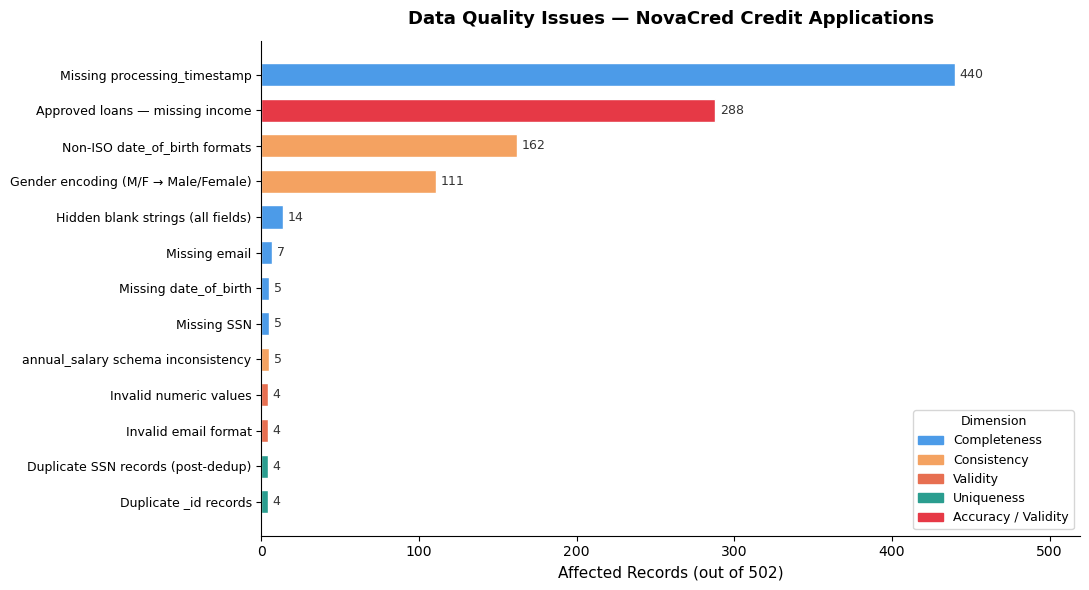

Chart saved to data/data_quality_summary.png


In [126]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# All identified issues: (label, affected_records, dimension)
issues_chart = [
    ("Missing processing_timestamp",         440, "Completeness"),
    ("Approved loans: missing income",       288, "Accuracy / Validity"),
    ("Non-ISO date_of_birth formats",        162, "Consistency"),
    ("Gender encoding (M/F → Male/Female)",  111, "Consistency"),
    ("Hidden blank strings (all fields)",     14, "Completeness"),
    ("Missing email",                          7, "Completeness"),
    ("annual_salary schema inconsistency",     5, "Consistency"),
    ("Missing SSN",                            5, "Completeness"),
    ("Missing date_of_birth",                  5, "Completeness"),
    ("Duplicate _id records",                  4, "Uniqueness"),
    ("Duplicate SSN records (post-dedup)",     4, "Uniqueness"),
    ("Invalid email format",                   4, "Validity"),
    ("Invalid numeric values",                 4, "Validity"),
]

# Sort ascending so largest bar is at the top
issues_chart.sort(key=lambda x: x[1])

labels = [x[0] for x in issues_chart]
counts = [x[1] for x in issues_chart]
dims   = [x[2] for x in issues_chart]

color_map = {
    "Completeness":        "#4C9BE8",
    "Consistency":         "#F4A261",
    "Validity":            "#E76F51",
    "Uniqueness":          "#2A9D8F",
    "Accuracy / Validity": "#E63946",
}
bar_colors = [color_map[d] for d in dims]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels, counts, color=bar_colors, edgecolor="white", height=0.65)

# Value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontsize=9, color="#333333")

# Legend
legend_patches = [mpatches.Patch(color=c, label=d) for d, c in color_map.items()]
ax.legend(handles=legend_patches, title="Dimension", loc="lower right",
          fontsize=9, title_fontsize=9)

ax.set_xlabel("Affected Records (out of 502)", fontsize=11)
ax.set_title("Data Quality Issues — NovaCred Credit Applications",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, max(counts) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("../data/data_quality_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to data/data_quality_summary.png")

## 1.10 Export cleaned dataset

In [127]:
OUTPUT_PATH = Path("../data/credit_applications_clean_final.csv")
df_final.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)
print("Rows:", len(df_final))

Saved: ../data/credit_applications_clean_final.csv
Rows: 498
